# 03 阈值：同一个模型，门槛不同，结果就不同

这一份不学新模型，只换个角度看 02 里的三个模型，回答三个问题：
1. 模型到底是怎么从"分数"变成"欺诈 / 正常"的？
2. 门槛（阈值）往上调、往下调，抓到的、漏掉的、误报的分别怎么变？
3. 02 里的发现"类别权重只是让模型更愿意喊欺诈"到底对不对？

前提：先跑过 02，Drive 里要有切好的 `train_scaled.csv` 和 `test_scaled.csv`。

## 0. 准备：中文字体 + 读 02 切好的数据

In [3]:
!apt-get -qq install -y fonts-noto-cjk > /dev/null
import glob
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = glob.glob('/usr/share/fonts/**/NotoSansCJK*-Regular.ttc', recursive=True)[0]
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['axes.unicode_minus'] = False

In [4]:
import os
import numpy as np
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')
DATA_DIR = '/content/drive/MyDrive/data-mining'
assert os.path.exists(f'{DATA_DIR}/train_scaled.csv'), '找不到切好的数据，请先完整运行 02'

train_df = pd.read_csv(f'{DATA_DIR}/train_scaled.csv')
test_df = pd.read_csv(f'{DATA_DIR}/test_scaled.csv')
feature_cols = [c for c in train_df.columns if c != 'Class']
X_train, y_train = train_df[feature_cols], train_df['Class']
X_test, y_test = test_df[feature_cols], test_df['Class']
print(f'训练集 {len(train_df)} 行，测试集 {len(test_df)} 行，测试集欺诈 {y_test.sum()} 笔')

Mounted at /content/drive
训练集 199391 行，测试集 85416 行，测试集欺诈 145 笔


## 1. 重新训练 02 的三个模型，拿到每笔测试交易的"可疑分数"

参数和 02 完全一样，随机种子也一样，所以结果和 02 一致。随机森林大约要 2 分钟。
- 逻辑回归、随机森林：分数是"欺诈概率"，0~1 之间。
- SVM：分数是到分界线的有符号距离，可以是负数，0 是它默认的分界。

分数存到 Drive，后面的融合实验还要用。

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

lr = LogisticRegression(class_weight='balanced', max_iter=1000).fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                            n_jobs=-1, random_state=42).fit(X_train, y_train)

N_NORMAL = 20000
svm_train = pd.concat([
    train_df[train_df.Class == 1],
    train_df[train_df.Class == 0].sample(N_NORMAL, random_state=42),
])
svm = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm.fit(svm_train[feature_cols], svm_train['Class'])

scores = pd.DataFrame({
    'Class': y_test.values,
    '逻辑回归': lr.predict_proba(X_test)[:, 1],
    '随机森林': rf.predict_proba(X_test)[:, 1],
    'SVM': svm.decision_function(X_test),
})
scores.to_csv(f'{DATA_DIR}/scores_classic.csv', index=False)
default_threshold = {'逻辑回归': 0.5, '随机森林': 0.5, 'SVM': 0.0}
scores.head()

,Class,逻辑回归,随机森林,SVM
0,0,0.030213,0.0,-0.525932
1,0,0.021441,0.0,-1.185877
2,0,0.061763,0.0,-2.124289
3,0,0.018103,0.0,-1.590249
4,0,0.021526,0.0,-1.150069


## 2. 分数长什么样

以逻辑回归为例，把测试集每笔交易的欺诈概率画成直方图，两类分开画。

**横轴**：模型给出的欺诈概率（0~1）。**纵轴**：落在这一段的交易笔数，用了对数刻度，否则 8 万多笔正常交易会把 145 笔欺诈压得看不见。**黑色竖线**：默认阈值 0.5，线右边的都被判成欺诈。

看什么：大部分正常交易挤在左边，大部分欺诈挤在右边，但两类在中间有重叠。阈值无论放在哪，重叠区里总有判错的——这就是为什么"抓得多"和"误报少"不能同时做到。

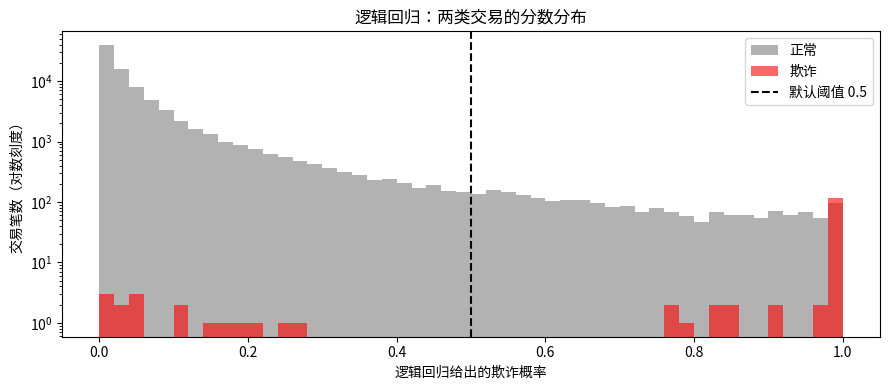

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, 1, 51)
for c, name, color in [(0, '正常', 'gray'), (1, '欺诈', 'red')]:
    ax.hist(scores.loc[scores.Class == c, '逻辑回归'], bins=bins, alpha=0.6, color=color, label=name)
ax.axvline(0.5, color='black', linestyle='--', label='默认阈值 0.5')
ax.set_yscale('log')
ax.set_xlabel('逻辑回归给出的欺诈概率')
ax.set_ylabel('交易笔数（对数刻度）')
ax.set_title('逻辑回归：两类交易的分数分布')
ax.legend()
plt.tight_layout()
plt.show()

## 3. 把阈值一档一档挪动，看笔数怎么变

同样是逻辑回归，换不同阈值，数一数抓到、漏掉、误报各多少笔。

In [7]:
def count_at(score, threshold):
    pred = score >= threshold
    fraud = scores['Class'].values == 1
    caught = int((pred & fraud).sum())
    missed = int((~pred & fraud).sum())
    false_alarm = int((pred & ~fraud).sum())
    flagged = caught + false_alarm
    return {
        '阈值': threshold,
        '抓到': caught,
        '漏掉': missed,
        '误报': false_alarm,
        'Recall': caught / (caught + missed),
        'Precision': caught / flagged if flagged else float('nan'),
    }

pd.DataFrame([count_at(scores['逻辑回归'].values, t)
              for t in [0.1, 0.3, 0.5, 0.7, 0.9, 0.99, 0.999]]).round(4)

,阈值,抓到,漏掉,误报,Recall,Precision
0,0.100,137,8,14248,0.9448,0.0095
1,0.300,129,16,4482,0.8897,0.0280
2,0.500,129,16,2186,0.8897,0.0557
3,0.700,129,16,1001,0.8897,0.1142
4,0.900,122,23,351,0.8414,0.2579
5,0.990,116,29,71,0.8000,0.6203
6,0.999,115,30,47,0.7931,0.7099


## 4. 三个模型的 PR 曲线

把阈值从高到低连续地挪一遍，每个阈值都得到一对（Recall, Precision），连起来就是 PR 曲线。曲线下的面积就是 AUPRC。

**横轴**：Recall（欺诈抓到的比例）。**纵轴**：Precision（喊欺诈的里面真是欺诈的比例）。**每条线上的圆点**：这个模型在默认阈值下的位置，也就是 02 那张表里的成绩。**灰色虚线**：瞎猜的水平，等于欺诈占比 0.17%。

看什么：
- 曲线越靠右上角越好：抓得多，误报还少。
- 同一条曲线上的点是同一个模型，只是门槛不同。02 里逻辑回归和随机森林"一个激进一个保守"，很大程度上只是它们的圆点落在各自曲线的不同位置。

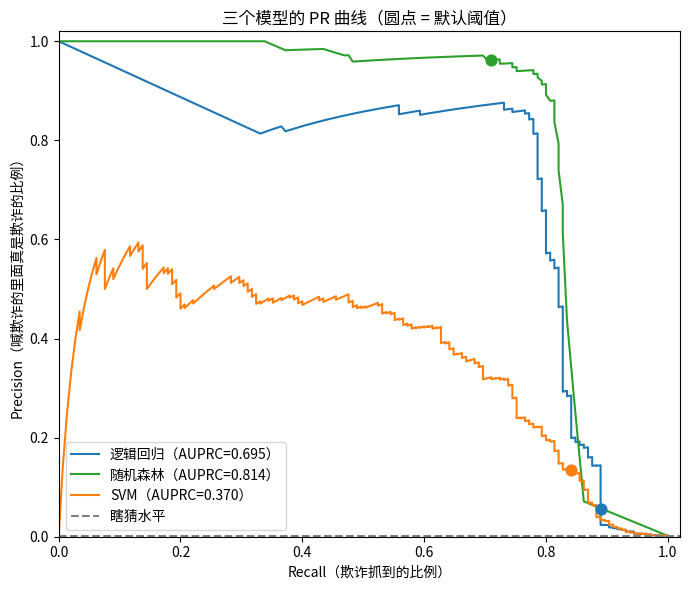

In [8]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(7, 6))
for name, color in [('逻辑回归', 'tab:blue'), ('随机森林', 'tab:green'), ('SVM', 'tab:orange')]:
    p, r, _ = precision_recall_curve(scores['Class'], scores[name])
    ap = average_precision_score(scores['Class'], scores[name])
    ax.plot(r, p, color=color, label=f'{name}（AUPRC={ap:.3f}）')
    d = count_at(scores[name].values, default_threshold[name])
    ax.scatter(d['Recall'], d['Precision'], color=color, s=60, zorder=3)

ax.axhline(scores['Class'].mean(), color='gray', linestyle='--', label='瞎猜水平')
ax.set_xlabel('Recall（欺诈抓到的比例）')
ax.set_ylabel('Precision（喊欺诈的里面真是欺诈的比例）')
ax.set_title('三个模型的 PR 曲线（圆点 = 默认阈值）')
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

## 5. 验证：类别权重是不是只相当于调低了阈值

再训练一个**不加**类别权重的逻辑回归，和加了权重的放在一起比：
- 左图：两者的 PR 曲线。如果几乎重合，说明两个模型"分辨能力"差不多。
- 右表：给不加权重的模型找一个更低的阈值，让它的 Recall 追上加权重的模型，看看这时的误报数是不是也差不多。

如果两边都对得上，就证明了 02 里的说法：类别权重主要是在挪门槛，而不是让模型更会分辨。

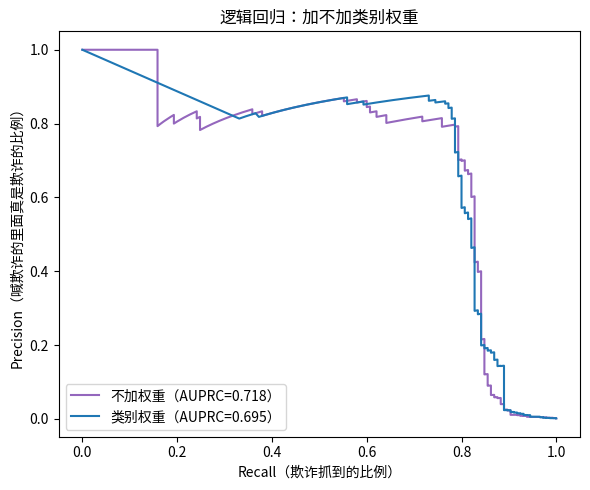

,阈值,抓到,漏掉,误报,Recall,Precision
模型,,,,,,
类别权重，阈值 0.5,0.5000,129,16,2186,0.8897,0.0557
不加权重，阈值调到 1.85e-03,0.0019,129,16,3072,0.8897,0.0403


In [9]:
lr_plain = LogisticRegression(max_iter=1000).fit(X_train, y_train)
plain = lr_plain.predict_proba(X_test)[:, 1]
weighted = scores['逻辑回归'].values

fig, ax = plt.subplots(figsize=(6, 5))
for name, s, color in [('不加权重', plain, 'tab:purple'), ('类别权重', weighted, 'tab:blue')]:
    p, r, _ = precision_recall_curve(scores['Class'], s)
    ax.plot(r, p, color=color, label=f'{name}（AUPRC={average_precision_score(scores["Class"], s):.3f}）')
ax.set_xlabel('Recall（欺诈抓到的比例）')
ax.set_ylabel('Precision（喊欺诈的里面真是欺诈的比例）')
ax.set_title('逻辑回归：加不加类别权重')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

target = count_at(weighted, 0.5)
fraud_scores = np.sort(plain[scores['Class'].values == 1])[::-1]
match = fraud_scores[target['抓到'] - 1]
pd.DataFrame([
    {'模型': '类别权重，阈值 0.5', **target},
    {'模型': f'不加权重，阈值调到 {match:.2e}', **count_at(plain, match)},
]).set_index('模型').round(4)

## 看完之后记下来（用你自己的话）

1. 第 2 节的直方图里，两类分数有没有重叠？重叠意味着什么？
2. 第 3 节，阈值从 0.1 调到 0.999，抓到和误报是怎么一起变的？你会选哪个阈值，为什么？
3. 第 4 节，三条 PR 曲线里谁最靠右上？02 里随机森林"保守"、逻辑回归"激进"，现在怎么理解？
4. 第 5 节，加不加类别权重，曲线重不重合？把不加权重的阈值调低后，误报数和加权重的接近吗？
5. 这些能怎么回答报告思考题 3：为什么不能只看一个指标？